# Problem set 4: example workflow

Import necessary modules:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.multiclass import OneVsOneClassifier

from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ExpSineSquared, WhiteKernel

## Exercise 12.1

Load `forest_training.csv` and `forest_testing.csv`. Assign y:

In [2]:
forest_training = pd.read_csv('forest_training.csv')
forest_testing = pd.read_csv('forest_testing.csv')
y = forest_training.iloc[:, 0]
y_test = forest_testing.iloc[:, 0]

Perform the LDA using 2, 4, 6, and 27 predictors. 
LDA does not require the predictors to be scaled as scaling will not change the classification results.

In [3]:
predictors_list = [2, 4, 6, 27]

print('Misclassification rate of the training and test data sets, respectively:')
for p in predictors_list:
    X = forest_training.iloc[:, 1:1+p]
    X_test = forest_testing.iloc[:, 1:1+p]

    lda = LinearDiscriminantAnalysis(solver="lsqr") # The solver will find C^(-1) using the least-square method.
    lda.fit(X, y)

    # lda.score is accuracy, so 1 - lda.score is the misclassification rate.    
    print(f'{p:2n} predictors: {1 - lda.score(X, y):.4f}, {1 - lda.score(X_test, y_test):.4f}')

Misclassification rate of the training and test data sets, respectively:
 2 predictors: 0.1414, 0.1969
 4 predictors: 0.1414, 0.2492
 6 predictors: 0.0909, 0.1969
27 predictors: 0.0202, 0.1723


We find that the model achieves better performance when the number of predictors increases. This is not enough to judge which one is a better model, though, as a model with many predictors naturally has a lower fitting error than a model with only a few predictors.

### Visualization

Here we visualize the LDA results of the model using two predictors. First, construct a plot function as below:

In [4]:
def plot_results(estimator, X, y, ax, eps=1):
    palette = {1:"#6a7fd2", 2:"#c67f66", 3:"#73a89d", 4:"#c62f4d"}    # colors for four classes. Made using Colorgorical (see ref[1]).
    palette_cmap = colors.ListedColormap(palette.values())    # For DecisionBoundaryDisplay
    
    # The DecisionBoundaryDisplay class helps visualize the classification boundaries of an estimator.
    DecisionBoundaryDisplay.from_estimator(estimator, 
                                           X,
                                           grid_resolution=400,
                                           plot_method='pcolormesh',
                                           ax=ax,
                                           cmap=palette_cmap,
                                           alpha=0.3,
                                           eps=eps,    # eps determines the padding of the pcolormesh area
                                          )
    # Group good and bad predictions 
    marker_colors = y.map(palette)
    good_pred = y - estimator.predict(X) == 0
    X_good_pred_np = X[good_pred].to_numpy()
    X_bad_pred_np = X[~good_pred].to_numpy()

    # Visualize good and bad predictions using circles and cross marks, respectively
    ax.scatter(X_good_pred_np[:, 0], X_good_pred_np[:, 1], c=marker_colors[good_pred], label='Correct predictions')
    ax.scatter(X_bad_pred_np[:, 0],  X_bad_pred_np[:, 1],  c=marker_colors[~good_pred], marker='x', label='Incorrect predictions')

    # Set legend with grey color
    legend = ax.legend(loc='upper left')
    for h in legend.legend_handles:
        h.set_color('gray')

Now rerun the case with two predictors and visualize the results.

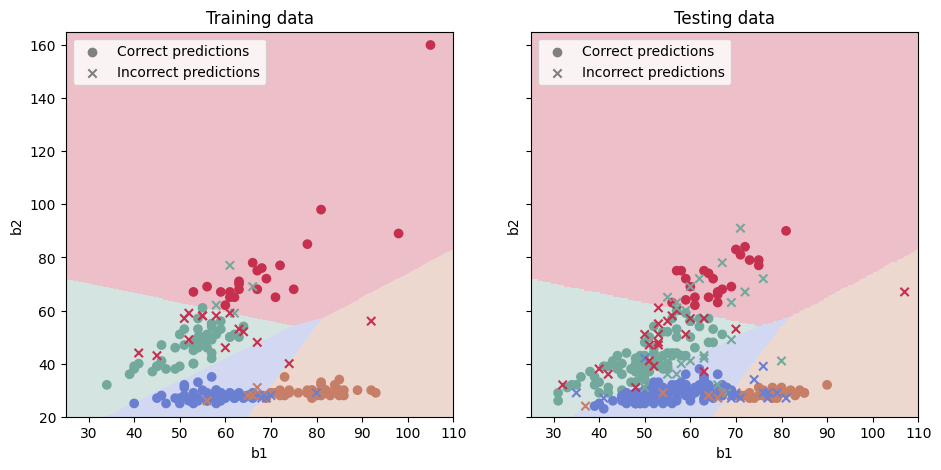

In [5]:
X = forest_training.iloc[:, 1:3]
X_test = forest_testing.iloc[:, 1:3]
lda = LinearDiscriminantAnalysis(solver="lsqr")
lda.fit(X, y);

fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
plot_results(lda, X, y, axs[0], eps=10)
plot_results(lda, X_test, y_test, axs[1], eps=75)
axs[0].set_xlim(25, 110)
axs[0].set_ylim(20, 165)
axs[0].set_title('Training data')
axs[1].set_title('Testing data');

For the legend:

- Marker style represents whether a data point is correctly classified (circle) or not (cross).
- Marker color represents the observed classifications ($y$).
- Four colored areas represent the modeled classifications and their boundaries ($\hat{y}$).

## Question 2

Unlike the LDA, the (non-linear case of) SVM requires the data to be scaled into similar range since the kernel trick heavily relies on the **distance between data points**. You can surely use the `StandardScaler` in a way we did in the previous assignment, but here I want to introduce scikit-learn's `make_pipeline` functionality in order to get better-wrapped estimators along with `SVC` and `OneVsOneClassifier`.

First, we perform the hyperparameter tuning using a five-fold cross-validation and a grid search approach. A support vector classifier (scikit-learn's `SVC`) with an RBF kernel has two tuning parameters: C and $\sigma$ (See Section 13.7.3 of Hsieh's textbook). `SVC` accepts C and $\gamma$ as tunable parameters, and $\gamma = \frac{1}{2\sigma}$.

In [6]:
c_list = [0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
gamma_list = [1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8]    # gamma = 1 / (2 * sigma)

results = np.zeros((8, 8))

for idx_c, c in enumerate(c_list):
    for idx_g, g in enumerate(gamma_list):
        
        # Create an SVC with RBF kernel 
        svm = SVC(kernel='rbf', C=c, gamma=g)

        # Wrap SVC with OneVsOneClassifier and combine it with StandardScaler in a pipeline
        clf = make_pipeline(StandardScaler(), OneVsOneClassifier(svm))

        # Perform CV and save the results
        cv_allscores = cross_val_score(clf, X, y, cv=5)
        cv_avgscore = cv_allscores.mean()
        results[idx_c, idx_g] = cv_avgscore

# Convert to pandas DataFrame for a nice print format
results_df = pd.DataFrame(results, c_list, gamma_list)

# C varies with row, and gamma varies with column
results_df

,0.0625,0.1250,0.2500,0.5000,1.0000,2.0000,4.0000,8.0000
0.03,0.298077,0.298077,0.414487,0.636667,0.672179,0.651795,0.454103,0.298077
0.10,0.515897,0.732821,0.823333,0.853590,0.848590,0.843590,0.782949,0.752692
0.30,0.828333,0.843718,0.863846,0.863590,0.853462,0.858590,0.858718,0.838462
1.00,0.863718,0.868718,0.863718,0.863718,0.858590,0.863718,0.868974,0.863846
3.00,0.868718,0.858590,0.858590,0.858590,0.858718,0.868974,0.873974,0.843718
10.00,0.863590,0.858590,0.858590,0.863718,0.873974,0.868846,0.853846,0.843590
30.00,0.858590,0.858590,0.863718,0.858718,0.873846,0.868846,0.858846,0.808077
100.00,0.858718,0.858846,0.878974,0.868718,0.873846,0.848718,0.843462,0.788077


As we can see, if we only use two predictors, it's actually hard to pick the best hyperparameters since many of them have a close performance score. So here we pick two sets: 

1. (C, $\gamma$) = $(1, 0.125)$  -> Small regularization term (enhancing boundary roughness) and large sigma (less non-linearity)
2. (C, $\gamma$) = $(10, 1)$ -> Big regularization term (suppressing boundary roughness) and small sigma (more non-linearity)

And let's use the `plot_results` function we just created in the previous question to visualize and compare the results:

Misclassification rate of the training and test data sets, respectively:
SVM (C=1, gamma=1/8): 0.1263, 0.1785
SVM (C=10, gamma=1 ): 0.1010, 0.2185


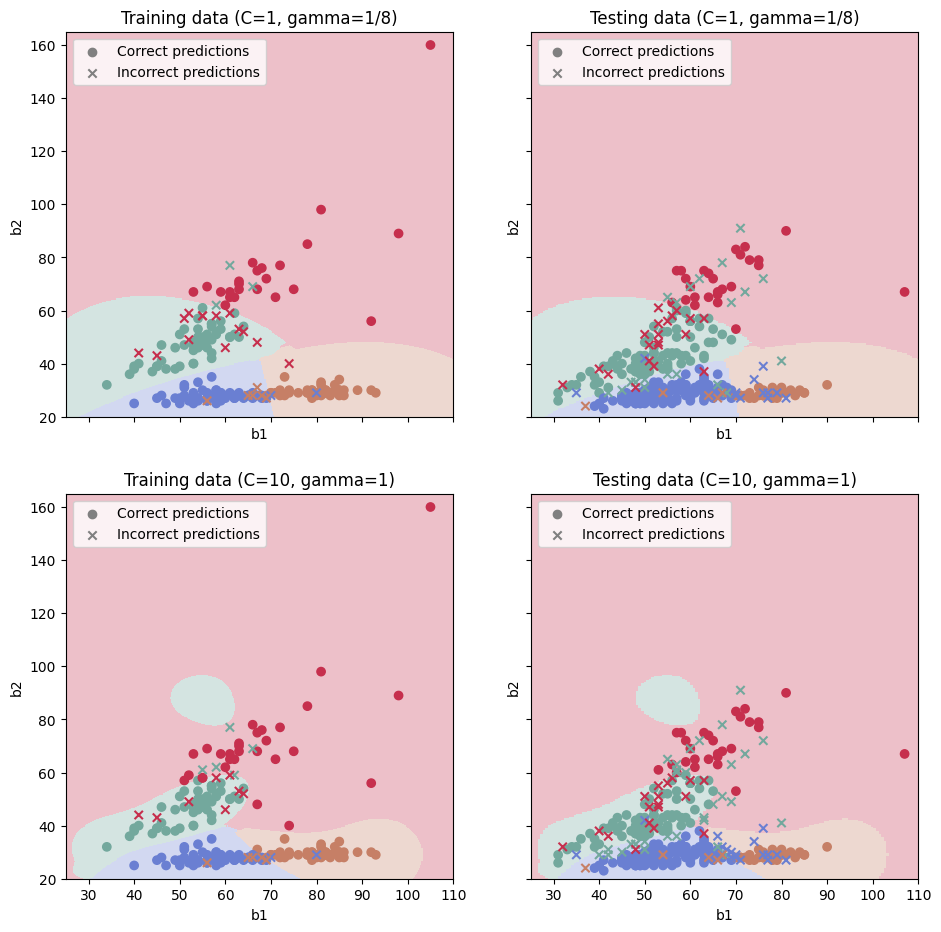

In [7]:
# Hyperparameter set #1
tuned_svm1 = SVC(kernel='rbf', C=1, gamma=0.125)
clf1 = make_pipeline(StandardScaler(), OneVsOneClassifier(tuned_svm1))
clf1.fit(X, y)

# Hyperparameter set #2
tuned_svm2 = SVC(kernel='rbf', C=10, gamma=1)
clf2 = make_pipeline(StandardScaler(), OneVsOneClassifier(tuned_svm2))
clf2.fit(X, y)

# Print evaluation metrics
print('Misclassification rate of the training and test data sets, respectively:')
print(f'SVM (C=1, gamma=1/8): {1 - clf1.score(X, y):.4f}, {1 - clf1.score(X_test, y_test):.4f}')
print(f'SVM (C=10, gamma=1 ): {1 - clf2.score(X, y):.4f}, {1 - clf2.score(X_test, y_test):.4f}')

# Visualization
fig, axs = plt.subplots(2, 2, figsize=(11, 11), sharex=True, sharey=True)
plot_results(clf1, X, y, axs[0, 0], eps=10)
plot_results(clf1, X_test, y_test, axs[0, 1], eps=75)
plot_results(clf2, X, y, axs[1, 0], eps=10)
plot_results(clf2, X_test, y_test, axs[1, 1], eps=75)
axs[0, 0].set_xlim(25, 110)
axs[0, 0].set_ylim(20, 165)
axs[0, 0].set_title('Training data (C=1, gamma=1/8)')
axs[0, 1].set_title('Testing data (C=1, gamma=1/8)');
axs[1, 0].set_title('Training data (C=10, gamma=1)')
axs[1, 1].set_title('Testing data (C=10, gamma=1)');

The classification results of the two models for the training data are very similar, but the boundary has a totally different extrapolation that slightly affects the performance of the testing data.

## Question 3

Let's generate the synthetic data first. Note that I randomly sampled the locations of x.

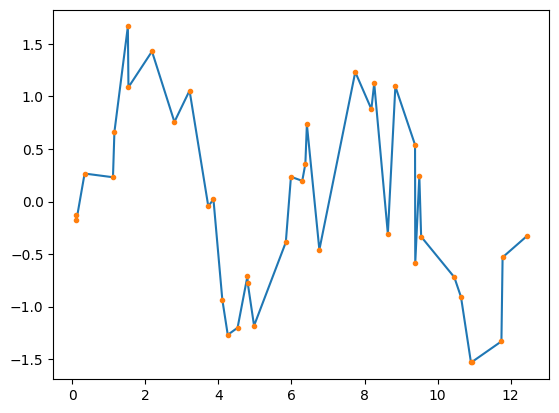

In [58]:
x = np.random.uniform(low=0, high=4 * np.pi, size=40)
x.sort()
X = x.reshape(-1, 1)
y_signal = np.sin(x)
y = y_signal + 0.5 * np.random.normal(scale=1.0, size=40)

# Prepare the coordinates for prediction 
x_pred = np.linspace(0, 8 * np.pi, 300)
X_pred = x_pred.reshape(-1, 1)

# To tune the hyperparameters for ridge and KR regressions, we split the data in half. 
X_train, X_vali, y_train, y_vali = train_test_split(X, y, train_size=20, shuffle=True)

# Visualize data
plt.plot(x, y)
plt.plot(x, y, '.')

First we tune $\lambda$ ($\alpha$ in scikit-learn's `Ridge` estimator) for our ridge regression. We use grid search again.

Best alpha = 1000.0


Text(0, 0.5, '$R^2$')

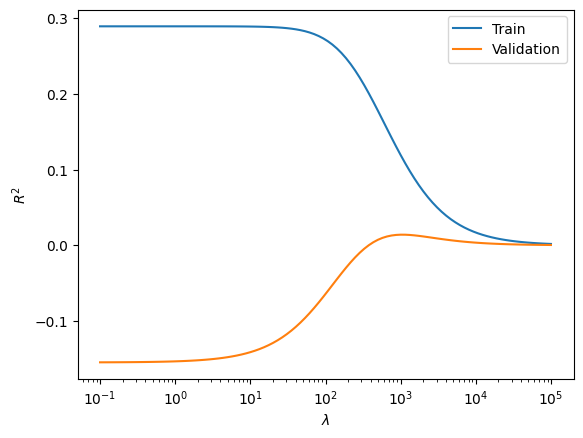

In [59]:
lbda_list = np.logspace(-1, 5, 100)
train_r2_list = np.zeros_like(lbda_list)
vali_r2_list = np.zeros_like(lbda_list)

for idx, lbda in enumerate(lbda_list):
    clf = Ridge(alpha=lbda, fit_intercept=True)
    clf.fit(X_train, y_train)
    train_r2_list[idx] = clf.score(X_train, y_train)
    vali_r2_list[idx] = clf.score(X_vali, y_vali)

# Select alpha with the highest validation R^2
alpha_for_ridge = lbda_list[np.argmax(vali_r2_list)]
print(f'Best alpha = {alpha_for_ridge}')

# Visualization
plt.semilogx(lbda_list, train_r2_list, label='Train')
plt.semilogx(lbda_list, vali_r2_list, label='Validation')
plt.legend()
plt.xlabel('$\lambda$')
plt.ylabel('$R^2$')

Next, we tune the hyperparameters for the KRR. We assume we already have some prior information that the signal is likely periodic with a period of 2$\pi$. Based on this, we select the `ExpSineSquared` kernel and let the periodicity hyperparameter to be fixed at 2$\pi$; that is, we do not tune the periodicity. The remaining hyperparameters are $\lambda$ ($\alpha$) and the `ExpSineSquared` kernel's length_scale, and we tune them using the grid search again. (See ref [2] for more details!)

Best alpha=0.7847599703514611, best length scale=0.29763514416313175


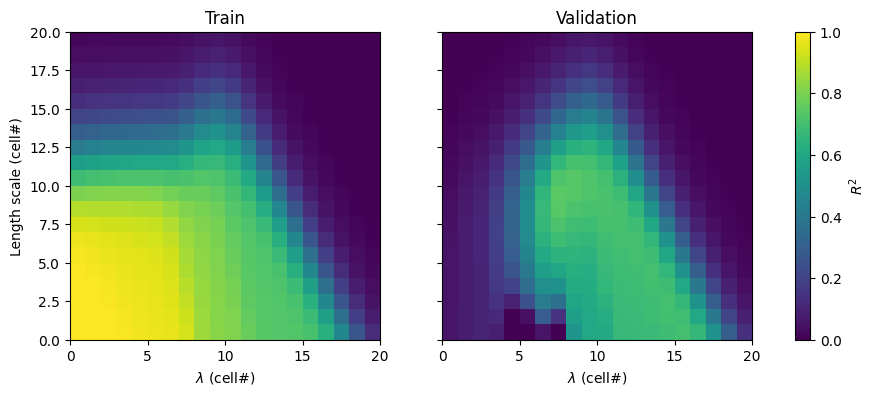

In [60]:
lbda_list = np.logspace(-2, 2, 20)
length_scale_list = np.logspace(-2, 2, 20)
train_r2_grid = np.zeros((len(lbda_list), len(length_scale_list)))
vali_r2_grid = np.zeros((len(lbda_list), len(length_scale_list)))

for idx_lbda, lbda in enumerate(lbda_list):
    for idx_ls, ls in enumerate(length_scale_list):

        kernel = ExpSineSquared(length_scale=ls, periodicity=2 * np.pi)
        clf = KernelRidge(alpha=lbda, kernel=kernel)
        clf.fit(X_train, y_train)
        train_r2_grid[idx_lbda, idx_ls] = clf.score(X_train, y_train)
        vali_r2_grid[idx_lbda, idx_ls] = clf.score(X_vali, y_vali)

# Select the coordinates in the hyperparameter space that produce the highest validation R^2
idx_lbda, idx_ls = np.unravel_index(np.argmax(vali_r2_grid), vali_r2_grid.shape)
alpha_for_krr = lbda_list[idx_lbda]
ls_for_krr = length_scale_list[idx_ls]
print(f'Best alpha={alpha_for_krr}, best length scale={ls_for_krr}')

# Visualization
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
pc1 = axs[0].pcolormesh(train_r2_grid, clim=(0, 1))
pc2 = axs[1].pcolormesh(vali_r2_grid, clim=(0, 1))
axs[0].set_title('Train')
axs[1].set_title('Validation')
axs[0].set_xlabel('$\lambda$ (cell#)')
axs[1].set_xlabel('$\lambda$ (cell#)')
axs[0].set_ylabel('Length scale (cell#)')
cbar = plt.colorbar(pc2, ax=fig.get_axes())
cbar.set_label('$R^2$')

For GPR, we use the same prior information to justify the use of the `ExpSineSquared` kernel again. Plus, we use a `WhiteKernel` to simulate the noise (see ref [2]). We don't need to tune the hyperparameter for GPR since they will be automatically tuned during the regression process (unless we fix them as a certain value -- if fact, we will do this for the periodicity again).

Finally, let's plot the results of three models together:

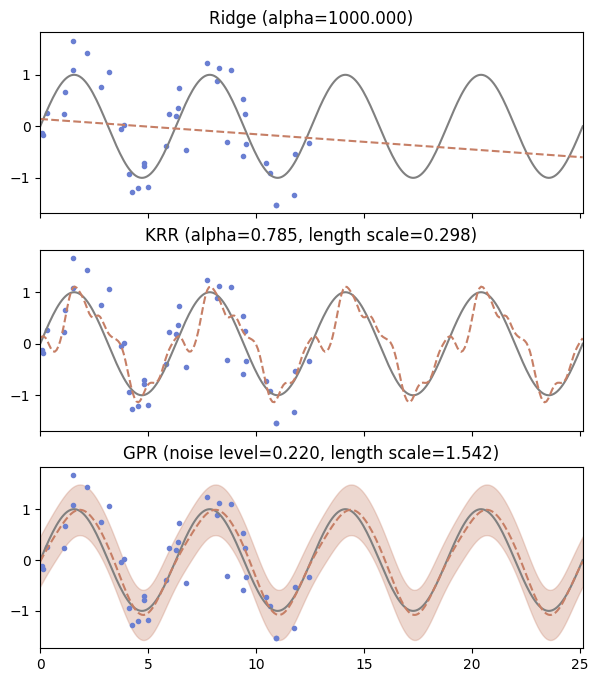

In [61]:
# Set kernels for KRR and GPR
krr_kernel = ExpSineSquared(length_scale=ls_for_krr, periodicity=2 * np.pi)
gpr_kernel = ExpSineSquared(length_scale=0.5, periodicity=2 * np.pi, periodicity_bounds='fixed') + WhiteKernel(0.5)

# Create a list for three estimators
estimator_list = [Ridge(alpha=alpha_for_ridge, fit_intercept=True),
                  KernelRidge(alpha=alpha_for_krr, kernel=krr_kernel),
                  GaussianProcessRegressor(kernel=gpr_kernel)]
label_list = [f'Ridge (alpha={alpha_for_ridge:.3f})', 
              f'KRR (alpha={alpha_for_krr:.3f}, length scale={ls_for_krr:.3f})', 
              f'GPR']

# Start regression and visualization
fig, axs = plt.subplots(3, 1, figsize=(7,8), sharex=True)
                  
for idx, clf in enumerate(estimator_list):
    # print(clf)
    clf.fit(X, y)
    y_pred = clf.predict(X_pred)
    axs[idx].plot(X, y, '.', c='#6a7fd2')               # data points
    axs[idx].plot(X_pred, np.sin(X_pred), 'gray')       # true signal
    axs[idx].plot(X_pred, y_pred, '--', c='#c67f66')    # prediction
    axs[idx].set_title(label_list[idx])                 # display the hyperparameters in the plot

# For GPR, we can also plot the confidence interval!
y_pred, y_pred_std = estimator_list[2].predict(X_pred, return_std=True)
axs[2].fill_between(X_pred.ravel(),
                    y_pred - y_pred_std,
                    y_pred + y_pred_std,
                    color='#c67f66',
                    alpha=0.3)

# Get the fine-tuned hyperparameters of the GPR kernels and show them in the plot
tuned_gpr_kernel = estimator_list[2].kernel_
tuned_gpr_kernel_params = tuned_gpr_kernel.get_params()
gpr_ls = tuned_gpr_kernel_params['k1__length_scale']
gpr_nl = tuned_gpr_kernel_params['k2__noise_level']
axs[2].set_title(label_list[2] + f' (noise level={gpr_nl:.3f}, length scale={gpr_ls:.3f})')
axs[0].set_xlim(0, 8 * np.pi);

Based on the results:

- Ridge regression does not do a good job since a linear regression cannot capture the non-linear pattern of the data. Instead, it just throws a really big regularization parameter during the tuning process that makes the regression line nearly flat.

- Kernel ridge regression (KRR) performs ridge regression in the feature space. In the data space, the fitting results are non-linear and show a period of 2$\pi$ because of the selection of the `ExpSineSquared` kernel.

- Gaussian process regression (GPR) also captures the periodical pattern. Compared with the KRR results, the modeled signal further resembles the shape of the squared sine wave (i.e., the kernel itself).

## References

1. Gramazio et al. (2017), Colorgorical: creating discriminable and preferable color palettes for information visualization. In *IEEE Transactions on Visualization and Computer Graphics.* http://vrl.cs.brown.edu/color (Accessed on June 1, 2025)
2. [Scikit-learn's KRR and GPR tutorial](https://scikit-learn.org/stable/auto_examples/gaussian_process/plot_compare_gpr_krr.html#sphx-glr-auto-examples-gaussian-process-plot-compare-gpr-krr-py)
3. [Scikit-learn's Support Vector Machines tutorial](https://scikit-learn.org/stable/modules/svm.html)
4. [Scikit-learn's Classifier comparison](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html)